In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [2]:
# Read the .csv file
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
path = root + "experiments_s.csv"
df = pd.read_csv(path, sep=';')
df.head(5)

,Task,Grounder,KGE,EmbedSize,WeightLoss_Task,Reasoner_depth,Model_name,Time,train_loss,train_concept_loss,...,test_concept_mrr,test_concept_hits@1@1,test_concept_hits@3@3,test_concept_hits@5@5,test_concept_hits@10@10,test_task_mrr,test_task_hits@1@1,test_task_hits@3@3,test_task_hits@5@5,"test_task_hits@10@10,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
0,train_S1_p,domainbody,complex,100,0.5,1,no_reasoner,"[27.328875494003295, 2.1582102287173583]","[2.5768, 0.0001]","[0.012, 0.0002]",...,"[0.9215, 0.0099]","[0.88, 0.0126]","[0.944, 0.0233]","[1.0, 0.0]","[1.0, 0.0]","[0.7321, 0.0418]","[0.592, 0.05]","[0.784, 0.0496]","[1.0, 0.0]","[1.0, 0.0]"
1,train_S1_p,domainbody,complex,100,0.5,1,dcr,"[43.75810141563416, 1.5653438916312172]","[0.02, 0.0006]","[0.0121, 0.0002]",...,"[0.9189, 0.0094]","[0.876, 0.015]","[0.94, 0.0219]","[1.0, 0.0]","[1.0, 0.0]","[0.917, 0.0112]","[0.876, 0.015]","[0.932, 0.0204]","[1.0, 0.0]","[1.0, 0.0]"
2,train_S1_p,domainbody,complex,100,0.5,1,r2n,"[45.89434728622437, 1.0722247599973396]","[0.0134, 0.0002]","[0.0121, 0.0002]",...,"[0.9253, 0.0092]","[0.888, 0.0098]","[0.94, 0.0219]","[1.0, 0.0]","[1.0, 0.0]","[0.9247, 0.0097]","[0.888, 0.0098]","[0.94, 0.0219]","[1.0, 0.0]","[1.0, 0.0]"
3,train_S1_p,domainbody,complex,100,0.5,1,sbr,"[32.89035143852234, 2.2004339762892955]","[0.0173, 0.0008]","[0.0142, 0.0005]",...,"[0.9397, 0.0121]","[0.912, 0.016]","[0.948, 0.024]","[1.0, 0.0]","[1.0, 0.0]","[0.9611, 0.0219]","[0.936, 0.0344]","[0.992, 0.0098]","[1.0, 0.0]","[1.0, 0.0]"
4,train_S1_p,domainbody,complex,100,0.5,1,rnm,"[30.905685043334962, 0.9638160766240549]","[0.013, 0.0001]","[0.0121, 0.0001]",...,"[0.9273, 0.0096]","[0.892, 0.0098]","[0.94, 0.0219]","[1.0, 0.0]","[1.0, 0.0]","[0.9317, 0.0092]","[0.892, 0.0098]","[0.972, 0.0204]","[1.0, 0.0]","[1.0, 0.0]"


In [3]:
# remove the duplicates in df
df = df.drop_duplicates( keep='first')

In [4]:
for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        df[column] = [np.array(eval(i)) for i in df[column].values]
        
    except:
        # print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(df[col].unique())
            print(col)
            print()
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]
# results

['train_S1_p' 'train_S2_p' 'train_S3_p']
Task

['domainbody' 'backward' 'known' 'full' 'domain']
Grounder

['complex' 'distmult' 'transe']
KGE

[100]
EmbedSize

[1]
Reasoner_depth

['no_reasoner' 'dcr' 'r2n' 'sbr' 'rnm' 'gsbr' 'cdcr']
Model_name



In [5]:
def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    for col in df_mean.columns:
        try:
            df_mean[col] = [i[0] for i in df_mean[col].values]
        except:
            continue
    # Do the same for the std
    df_std = df.copy()
    for col in df_std.columns:
        try:
            df_std[col] = [i[1] for i in df_std[col].values]
        except:
            continue
    return df_mean, df_std

# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [73]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
cols = 'Grounder'
rows = 'Model_name'
metrics = ['test_task_mrr', 'Time']
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
tasks = ['train_S1_p','train_S2_p','train_S3_p']
for task in tasks:
    for metric in metrics:
        for KGE in ['complex', 'distmult', 'transe']:
            print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task)
            # filter the df
            results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, test_task_mrr, test_concept_mrr
            results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
            # check if there are duplicates 
            # print(results.duplicated().sum())
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)
            if metric == 'test_task_mrr':
                # in the column no_reasoner, put the values of the column test_concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model] 

            print(results) 
            with open(csv_dir, 'a') as f:
                f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
                f.write('\n ') 
            results.to_csv(csv_dir, mode='a', header=True)  
results

KGE:  complex  Metric:  test_task_mrr  Task:  train_S1_p
Grounder             backward            domain        domainbody  \
Model_name                                                          
cdcr         [0.9089, 0.0206]  [0.9099, 0.0119]  [0.9117, 0.0169]   
dcr           [0.9206, 0.011]  [0.9221, 0.0144]   [0.917, 0.0112]   
gsbr         [0.9136, 0.0201]  [0.9173, 0.0182]  [0.9132, 0.0191]   
no_reasoner  [0.9215, 0.0099]  [0.9215, 0.0099]  [0.9215, 0.0099]   
r2n          [0.9224, 0.0153]  [0.9281, 0.0044]  [0.9247, 0.0097]   
rnm          [0.9317, 0.0138]   [0.937, 0.0068]  [0.9317, 0.0092]   
sbr          [0.9617, 0.0184]  [0.9567, 0.0202]  [0.9611, 0.0219]   

Grounder                 full             known  
Model_name                                       
cdcr         [0.9114, 0.0099]  [0.9239, 0.0126]  
dcr          [0.9199, 0.0116]  [0.9424, 0.0272]  
gsbr         [0.9095, 0.0229]  [0.9251, 0.0246]  
no_reasoner  [0.9215, 0.0099]  [0.9215, 0.0099]  
r2n          [0.9281,

Grounder,backward,known
Model_name,,
cdcr,"[1887.8994427680968, 11.102530072932856]","[37.66969270706177, 6.534272333280847]"
dcr,"[816.5786633968353, 6.63477545083369]","[29.333427810668944, 4.9112715032214105]"
gsbr,"[286.7241252422333, 4.1243259576760005]","[21.917429065704347, 4.91158765480205]"
no_reasoner,"[18.047143125534056, 2.515019587310359]","[18.334918212890624, 4.822215033475863]"
r2n,"[1226.1721673488616, 11.696139503990818]","[24.551477003097535, 5.121688340686684]"
rnm,"[187.46604928970336, 5.654118835404622]","[21.06819396018982, 5.006820092079199]"
sbr,"[187.02018117904663, 2.0121757164631586]","[20.518449687957762, 4.775761373628392]"


In [61]:
# # Table 1: rows:grounder, cols:Model, values: mrr
# csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
# cols = 'Grounder'
# rows = 'KGE'
# metrics = ['test_task_mrr','Time']
# for metric in metrics:
#     for model in df['Model_name'].unique():
#         # filter the df
#         results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#         # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#         results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#         # put the model_name as colums
#         results = results.pivot(index=rows, columns=cols, values=metric)
#         # print(results)
#         # with open(csv_dir, 'a') as f:
#         #     f.write('\nModel : ,' + model + ', Metric: ,' + metric)
#         #     f.write('\n ')
#         # results.to_csv(csv_dir, mode='a', header=True)  
# results

# PLOTS

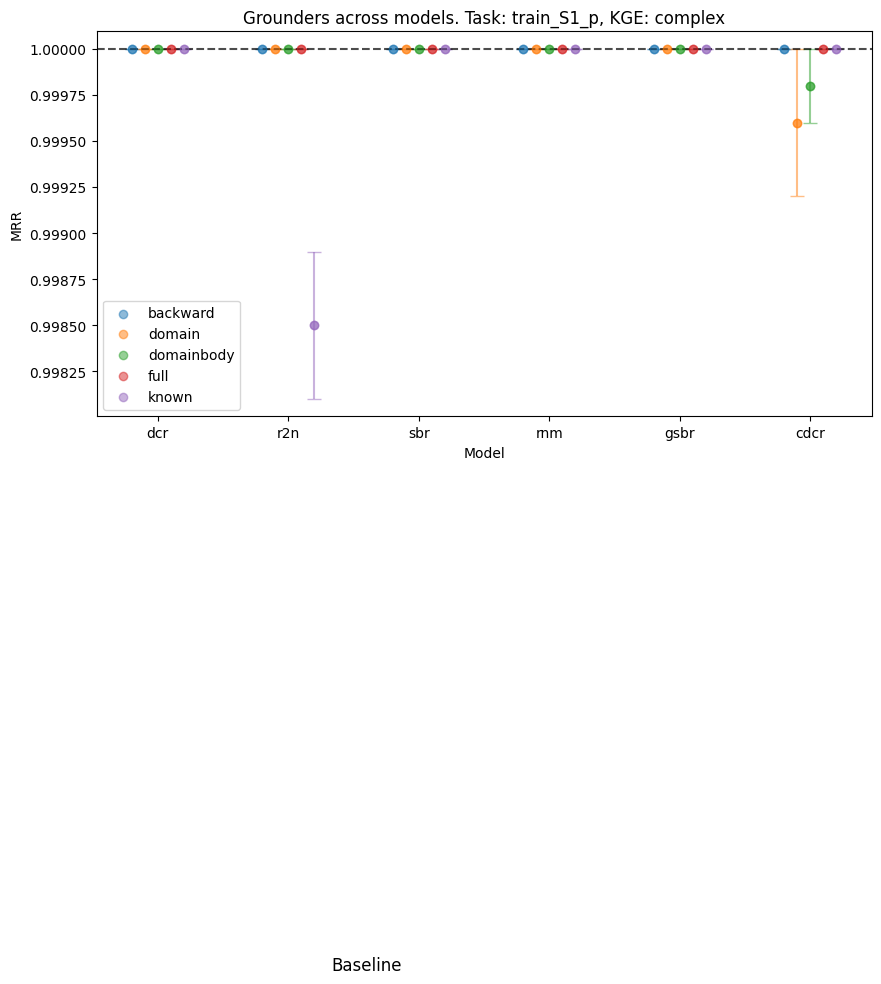

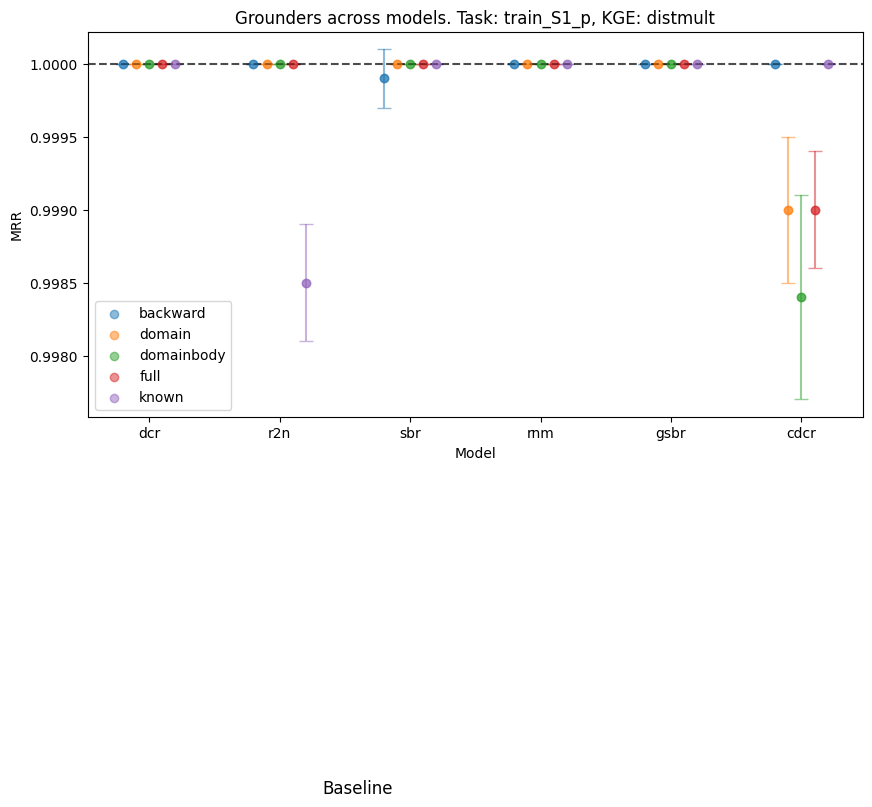

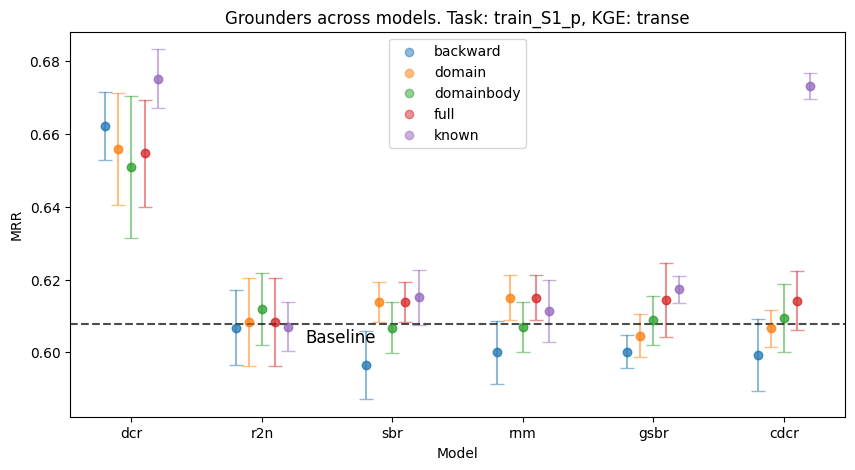

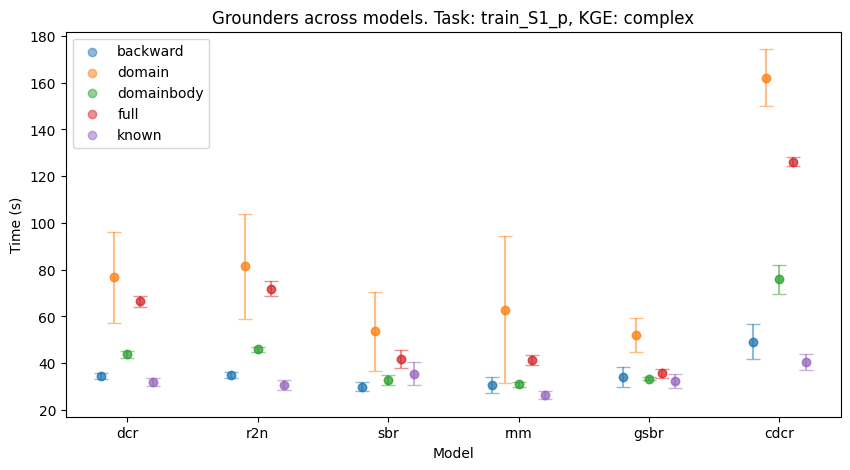

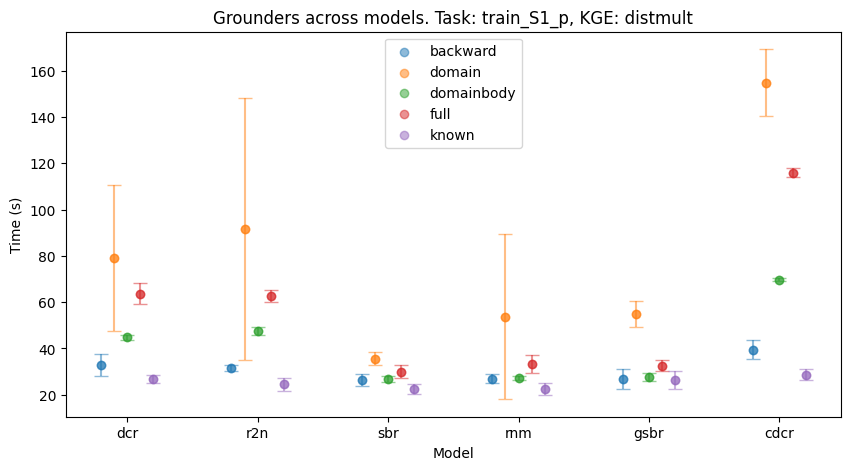

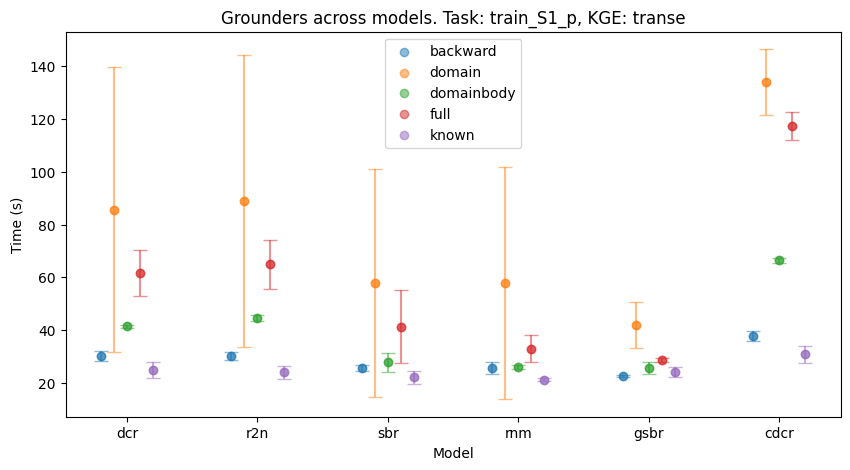

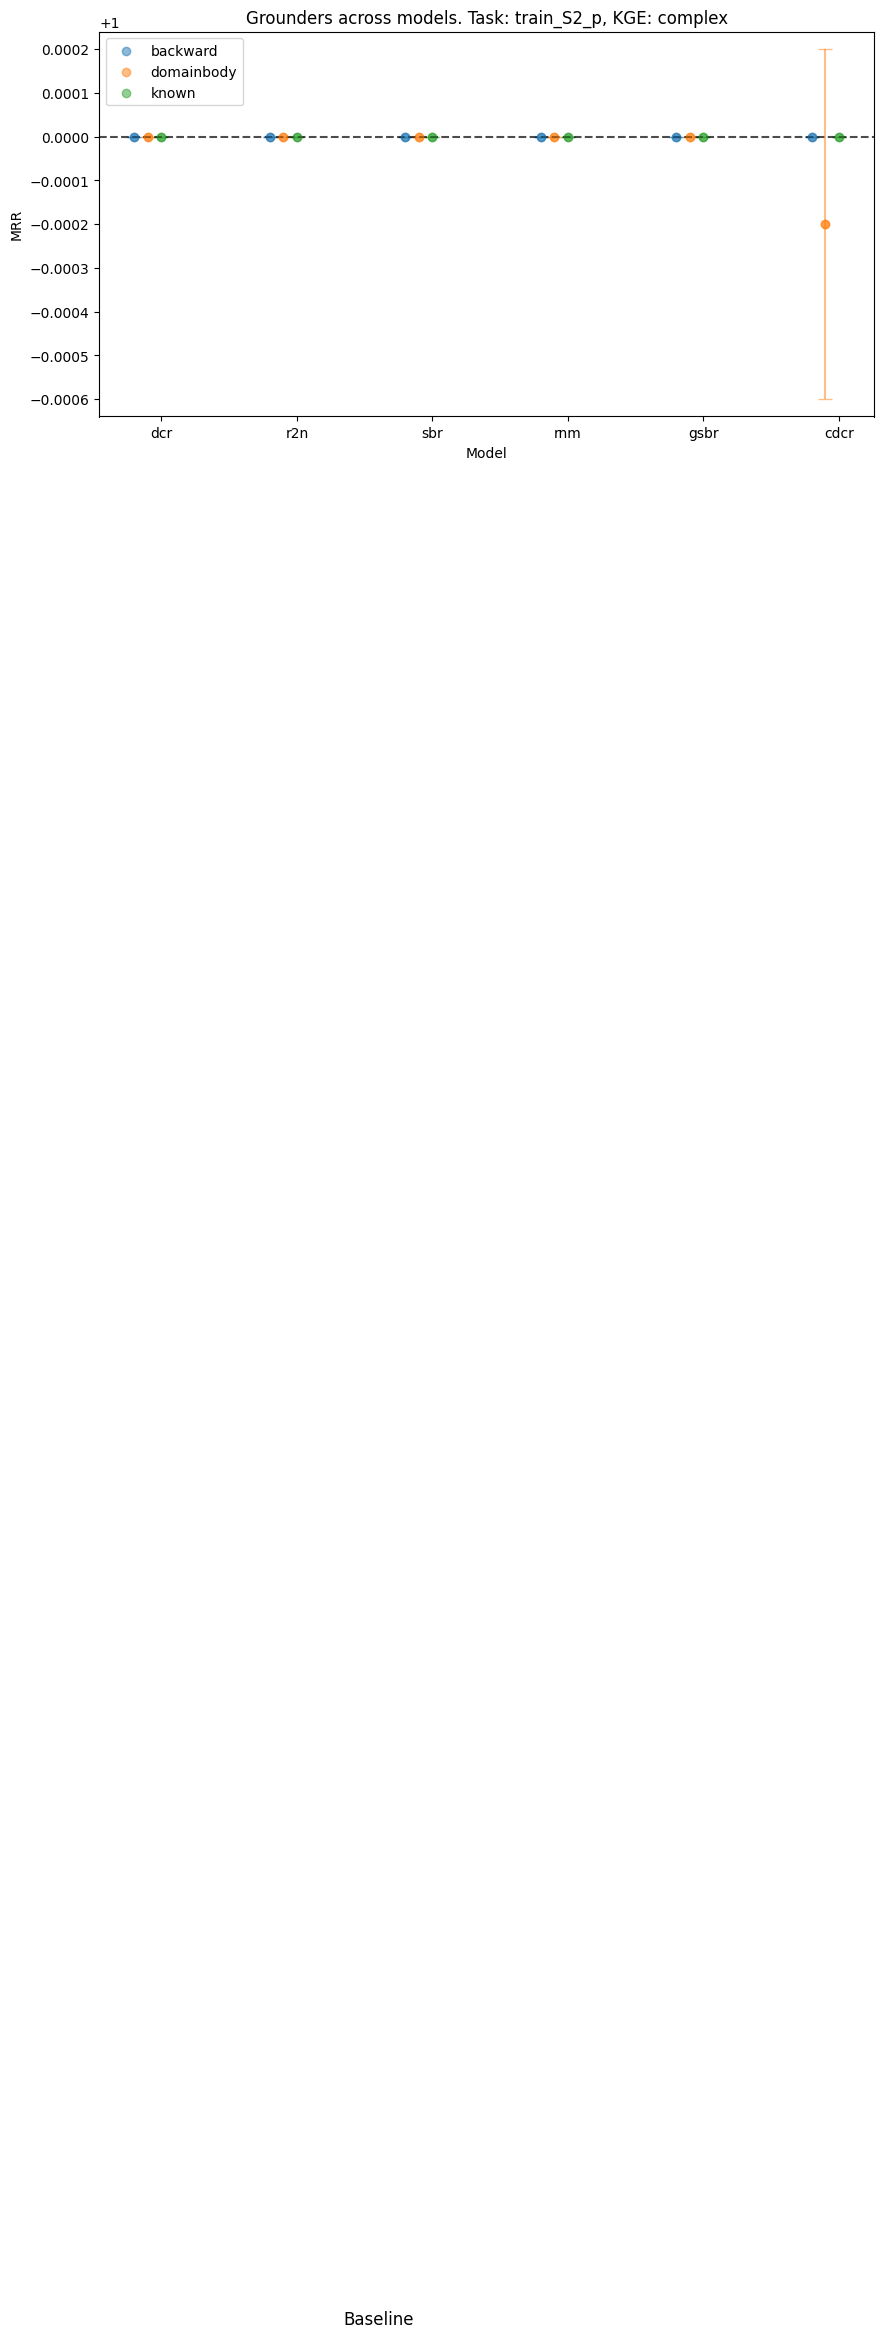

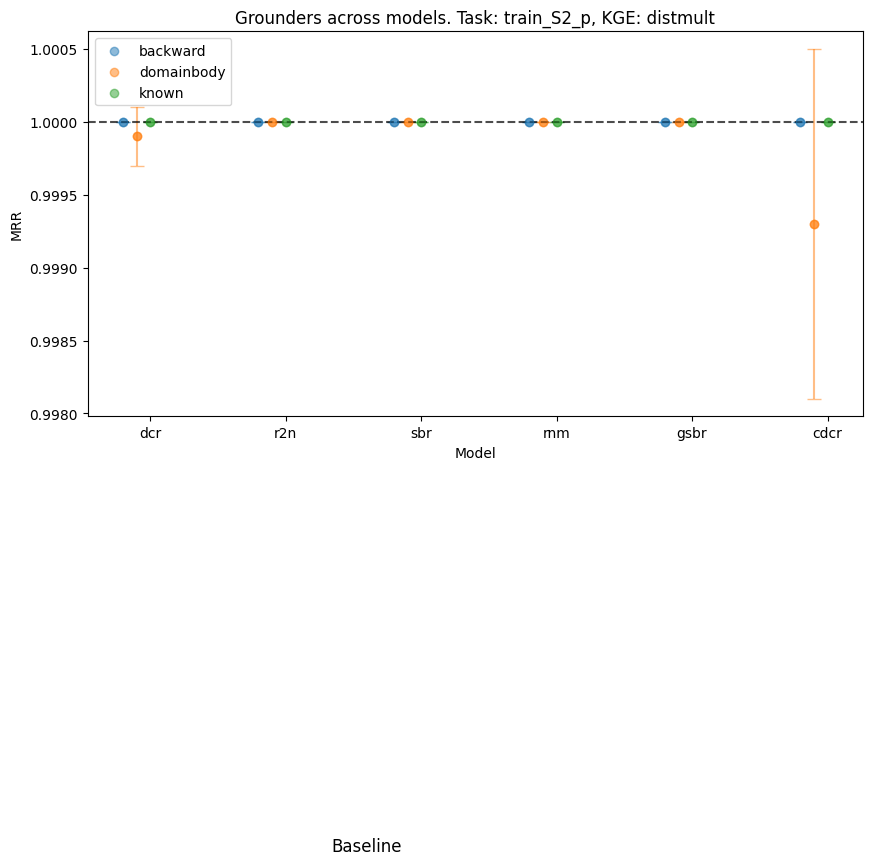

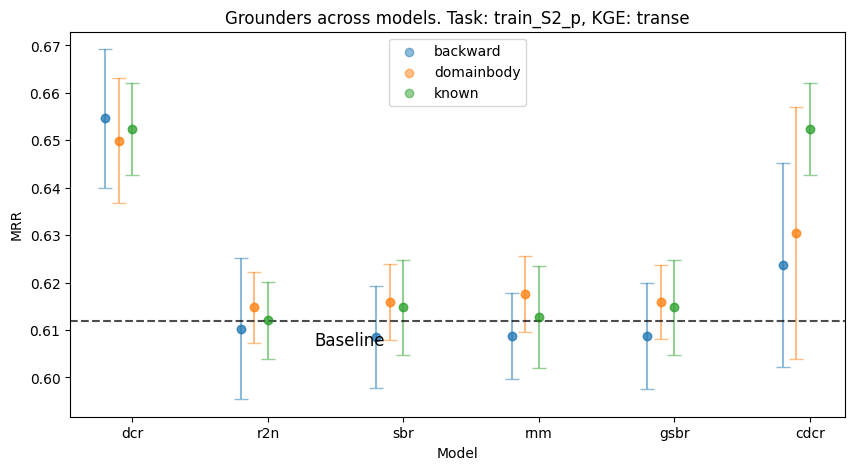

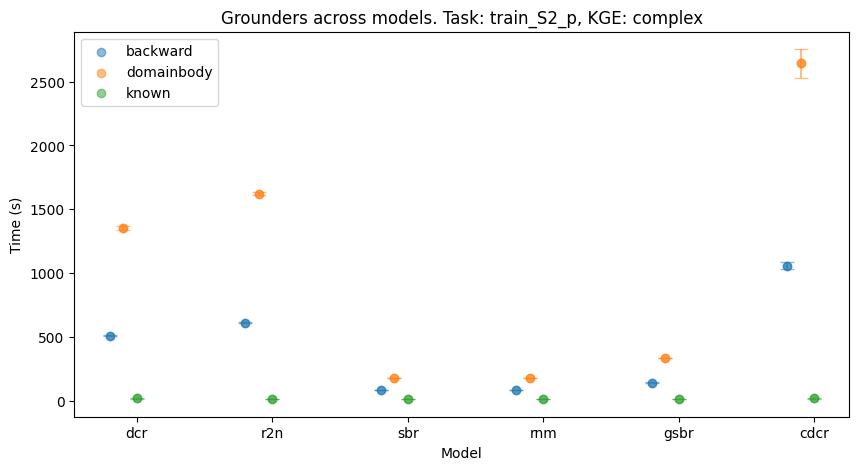

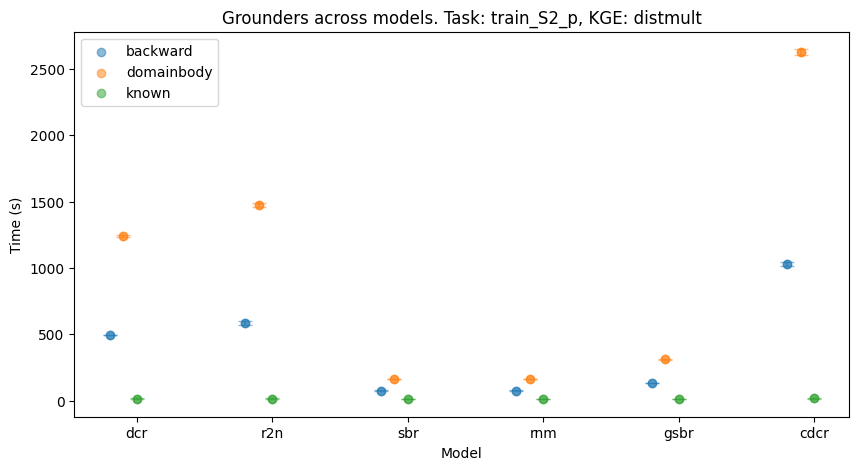

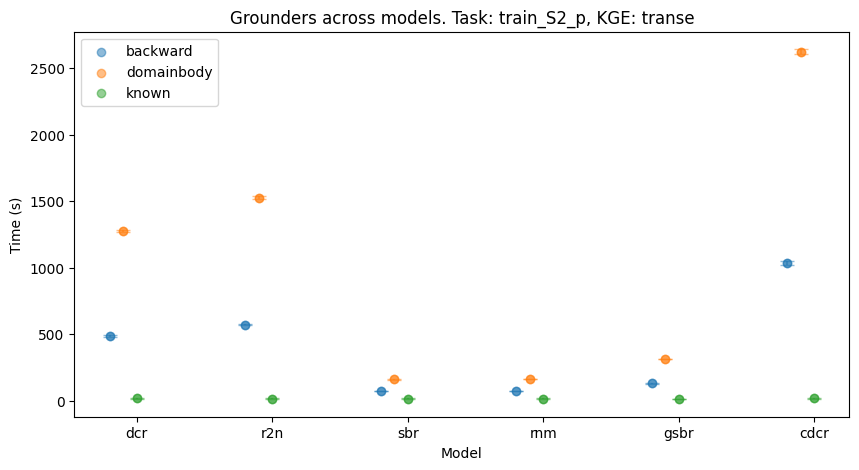

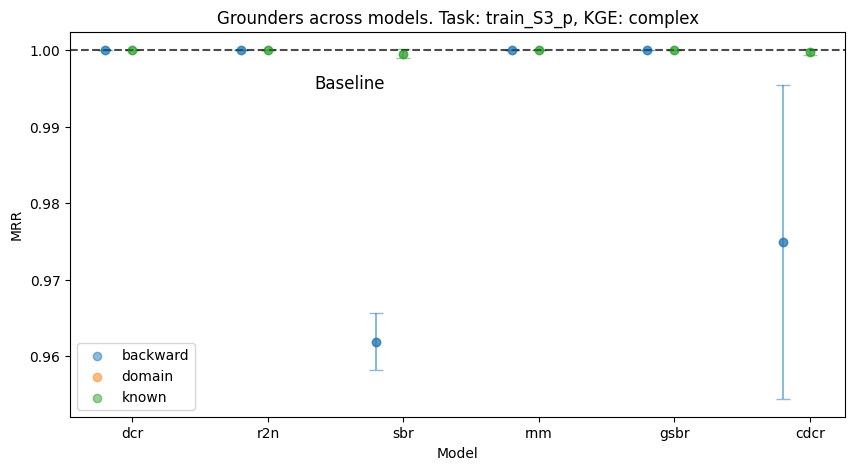

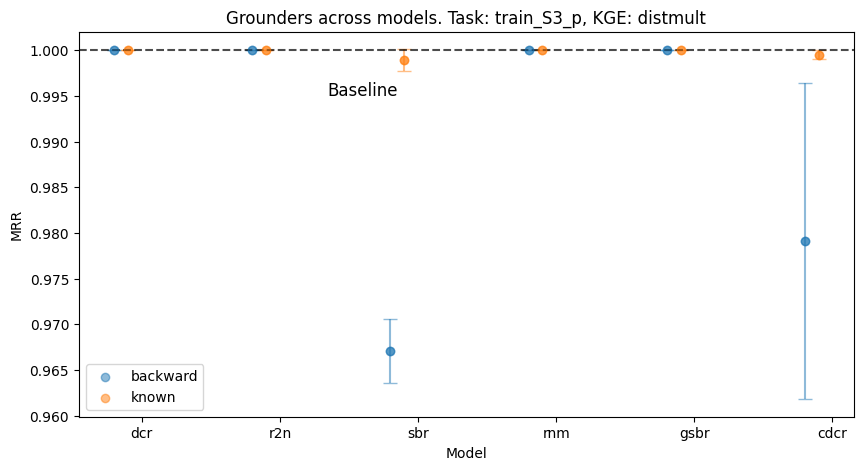

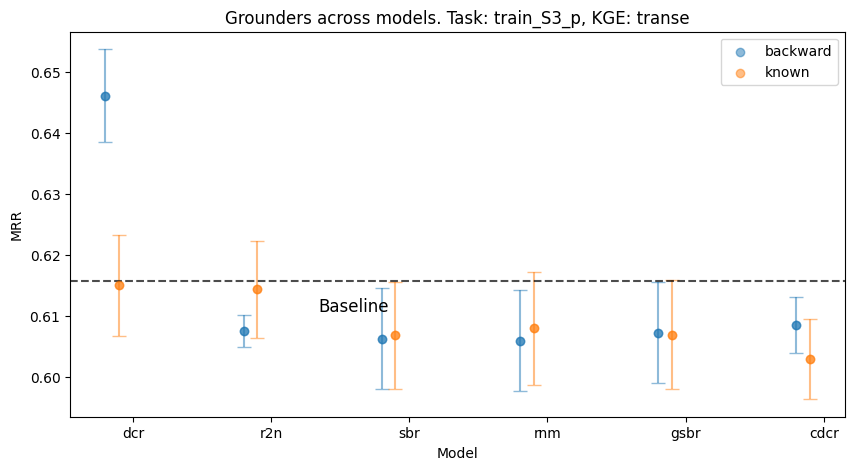

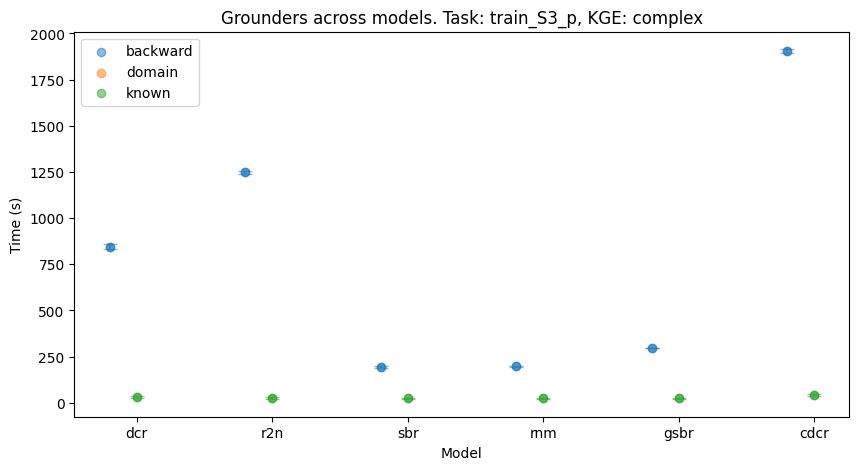

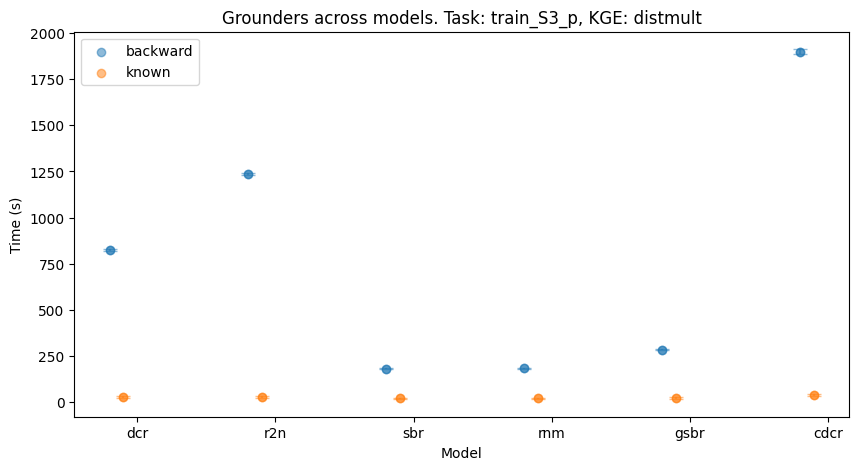

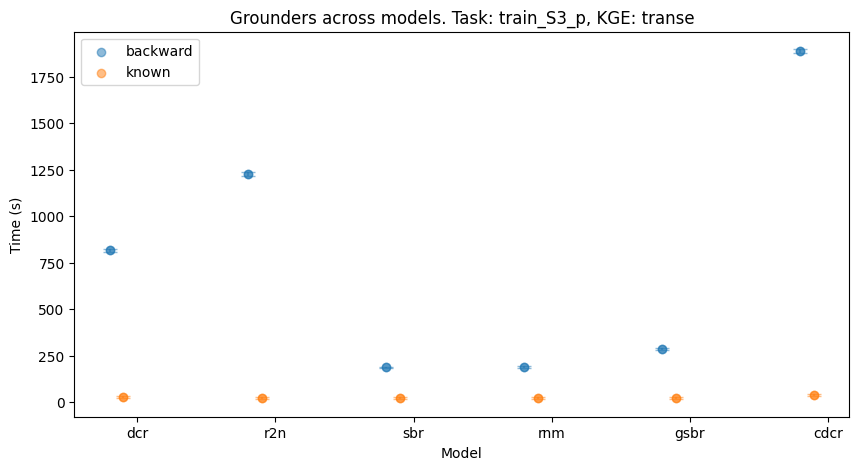

In [6]:
# Table 1: rows:grounder, cols:Model, values: mrr
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
cols = 'Grounder'
rows = 'Model_name'
metric = 'train_task_mrr'
models = ['dcr','r2n','sbr','rnm','gsbr','cdcr']
baseline_model = 'no_reasoner'
baseline_metric = 'train_concept_mrr'
tasks = ['train_S1_p','train_S2_p','train_S3_p']
metrics = ['train_task_mrr','Time']
metric_names = {'train_task_mrr':'MRR', 'Time':'Time (s)'}
for task in tasks:
    for metric in metrics:
        for KGE in ['complex', 'distmult', 'transe']:
            # filter the df
            results = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, train_task_mrr, train_concept_mrr
            results = results[[cols, rows, metric]]#, 'train_concept_mrr']]
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)

            if metric == 'train_task_mrr':
                # in the column no_reasoner, put the values of the column train_concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model]
            df_mean, df_std = split_df(results)
            # print(df_mean)
            # Remove no reasoner and include a line where it is written baseline
            plt.figure(figsize=(10,5))
            for i,grounder in enumerate(df_mean.columns):
                plt.scatter(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], label=grounder, alpha=0.5)
                plt.errorbar(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], yerr=df_std.loc[models][grounder], fmt='o',capsize=5, alpha=0.5)
            if metric == 'train_task_mrr':
                plt.axhline(y=df_mean.loc[baseline_model].values[0], color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                plt.text(1.8, df_mean.loc[baseline_model].values[0]-0.005, 'Baseline', color='black', fontsize=12, ha='center')
                # print(df_mean.loc[baseline_model].values[0])
            plt.legend()
            plt.xticks(np.arange(len(df_mean.loc[models].index))+0.2, df_mean.loc[models].index.tolist(), rotation=0)
            plt.ylabel(metric_names[metric])
            plt.xlabel('Model')
            plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}')
            # plt.show()
            # SAVE THE FIGURE
            plt.savefig(root_dir+'figures\\Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'.png', dpi=300, bbox_inches='tight')  

In [10]:
# cols = 'Grounder'
# rows = 'KGE'
# metric = 'test_task_mrr'
# baseline_model = 'no_reasoner'
# baseline_metric = 'test_concept_mrr'
# for metric in ['test_task_mrr', 'Time']:
#     for model in df['Model_name'].unique():
#         if model !='no_reasoner':
#             # filter the df
#             results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#             # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#             results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#             # put the model_name as colums
#             results = results.pivot(index=rows, columns=cols, values=metric)

#             df_mean, df_std = split_df(results)
#             # Remove no reasoner and include a line where it is written baseline
#             plt.figure(figsize=(10,5))
#             for i,grounder in enumerate(df_mean.columns):
#                 plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
#             plt.legend()
#             plt.xticks(np.arange(len(df_mean.index))+0.1*i, df_mean.index.tolist(), rotation=0)
#             plt.ylabel('MRR test')
#             plt.xlabel('KGE')
#             plt.title(f'Grounders across KGEs for model {model}')
#             plt.show()
#             # plt.savefig(root_dir+'figures\\Grounders_across_KGE___Model_'+model+'.png', dpi=300, bbox_inches='tight')  